# NBA Head-To-Head

**Goal**: Let's make two models, one that predicts home points, and another that predicts away points. Use same input data for now, but different outputs.

## Data

In [1]:
import pandas as pd

### Original Dataset

Need to kind of dissect what previously went on between these two datasets. I'll join back the Home/Away PTS afterwards.

In [13]:
# Load the datasets
features_df = pd.read_csv("nba_features_with_team_context.csv")
master_df = pd.read_csv("nba_master_dataset_2015_2025.csv")

# Get column sets
features_cols = set(features_df.columns)
master_cols = set(master_df.columns)

# Columns in features_df but not in master_df
features_not_in_master = features_cols - master_cols

# Columns in master_df but not in features_df
master_not_in_features = master_cols - features_cols

print("Columns in nba_features_with_team_context.csv but not in nba_master_dataset_2015_2025.csv:")
print(features_not_in_master)

print("\nColumns in nba_master_dataset_2015_2025.csv but not in nba_features_with_team_context.csv:")
print(master_not_in_features)

Columns in nba_features_with_team_context.csv but not in nba_master_dataset_2015_2025.csv:
{'Avg_Rolling_Pace_7g', 'Rolling_DefRating_Diff_10g', 'AwayTeam_Minnesota Timberwolves', 'OffRating_Diff', 'AwayTeam_New York Knicks', 'HomeTeam_Detroit Pistons', 'AwayTeam_Phoenix Suns', 'HomeTeam_San Antonio Spurs', 'Pace_Diff', 'HomeTeam_Los Angeles Lakers', 'AwayTeam_Orlando Magic', 'AwayTeam_Golden State Warriors', 'NetRating_Diff', 'HomeTeam_Chicago Bulls', 'AwayTeam_Brooklyn Nets', 'AwayTeam_Philadelphia 76ers', 'HomeTeam_Charlotte Hornets', 'HomeTeam_Miami Heat', 'HomeTeam_Brooklyn Nets', 'AwayTeam_Los Angeles Lakers', 'AwayTeam_Milwaukee Bucks', 'AwayTeam_Utah Jazz', 'AwayTeam_San Antonio Spurs', 'HomeTeam_Indiana Pacers', 'HomeTeam_Denver Nuggets', 'Avg_Rolling_Pace_10g', 'AwayTeam_Memphis Grizzlies', 'HomeTeam_Orlando Magic', 'AwayTeam_Charlotte Hornets', 'BackToBack_Sum', 'DefRating_Diff', 'Rolling_OffRating_Diff_10g', 'HomeTeam_Cleveland Cavaliers', 'HomeTeam_Sacramento Kings', 'Away

In [15]:
# Add HomePTS and AwayPTS columns from master_df to features_df by joining on GameDate and HomeTeam/AwayTeam

# First, ensure GameDate columns are datetime for both dataframes
features_df['GameDate'] = pd.to_datetime(features_df['GameDate'])
master_df['GameDate'] = pd.to_datetime(master_df['GameDate'])

# Find the home and away team columns in features_df
home_team_col = [col for col in features_df.columns if col.startswith('HomeTeam_')]
away_team_col = [col for col in features_df.columns if col.startswith('AwayTeam_')]

# Get the home and away team names for each row in features_df
def get_team(row, prefix):
    for col in row.index:
        if col.startswith(prefix) and row[col]:
            return col.replace(prefix, '')
    return None

features_df['HomeTeam'] = features_df.apply(lambda row: get_team(row, 'HomeTeam_'), axis=1)
features_df['AwayTeam'] = features_df.apply(lambda row: get_team(row, 'AwayTeam_'), axis=1)

# Merge on GameDate, HomeTeam, AwayTeam
features_df = features_df.merge(
    master_df[['GameDate', 'HomeTeam', 'AwayTeam', 'HomePTS', 'AwayPTS']],
    on=['GameDate', 'HomeTeam', 'AwayTeam'],
    how='left'
)

features_df = features_df.drop(columns=['HomeTeam', 'AwayTeam'])

In [16]:
display(features_df.head())

,GameDate,Avg_Pace,Pace_Diff,OffRating_Diff,DefRating_Diff,NetRating_Diff,Rest_Days_Diff,BackToBack_Sum,Avg_Rolling_Pace_5g,Pace_Diff_Rolling_5g,...,AwayTeam_Philadelphia 76ers,AwayTeam_Phoenix Suns,AwayTeam_Portland Trail Blazers,AwayTeam_Sacramento Kings,AwayTeam_San Antonio Spurs,AwayTeam_Toronto Raptors,AwayTeam_Utah Jazz,AwayTeam_Washington Wizards,HomePTS,AwayPTS
0,2015-10-29,97.60,-3.6,3.2,-1.8,-6.9,-1.0,1,NaN,NaN,...,False,False,False,False,False,False,False,False,101,112
1,2015-11-01,98.60,-1.6,6.3,1.2,-0.8,0.0,0,NaN,NaN,...,False,False,False,False,False,False,False,False,92,94
2,2015-11-03,97.55,-3.7,5.4,1.5,-1.5,0.0,0,NaN,NaN,...,False,False,False,False,False,False,False,False,92,98
3,2015-11-06,99.15,-0.5,4.4,-4.3,-8.2,1.0,0,NaN,NaN,...,False,False,False,False,False,False,False,False,115,121
4,2015-11-13,100.25,1.7,5.1,2.1,-1.1,0.0,0,NaN,NaN,...,False,False,False,False,False,False,False,False,106,93


In [17]:
features_df.to_parquet("nba_features.parquet", index=False)

### Removing Home/Away Team Information

Let's just try reconstructing.

In [1]:
import pandas as pd
import time
from nba_api.stats.endpoints import leaguegamelog, teamestimatedmetrics, leaguedashplayerstats, boxscoretraditionalv2

# ----------------------------------
# Step 1: Pull Game Logs + Team Stats
# ----------------------------------

def get_game_logs_for_season(season: str, season_type: str = "Regular Season"):
    print(f"Fetching game logs for {season}...")
    games = leaguegamelog.LeagueGameLog(season=season, season_type_all_star=season_type)
    df = games.get_data_frames()[0]
    df["Season"] = season
    return df

def get_team_metrics_for_season(season: str):
    print(f"Fetching team metrics for {season}...")
    metrics = teamestimatedmetrics.TeamEstimatedMetrics(season=season)
    df = metrics.get_data_frames()[0]
    df["Season"] = season
    return df

def pull_all_game_and_team_data(start_year=2015, end_year=2025):
    seasons = [f"{year}-{str(year+1)[-2:]}" for year in range(start_year, end_year + 1)]
    all_game_logs = []
    all_team_metrics = []

    for season in seasons:
        try:
            game_log = get_game_logs_for_season(season)
            team_metrics = get_team_metrics_for_season(season)
            all_game_logs.append(game_log)
            all_team_metrics.append(team_metrics)
            print(f"Completed season {season}")
            time.sleep(1.5)  # basic rate limit protection
        except Exception as e:
            print(f"Error pulling season {season}: {e}")
            time.sleep(5)

    games_df = pd.concat([df for df in all_game_logs if not df.empty], ignore_index=True)
    teams_df = pd.concat([df for df in all_team_metrics if not df.empty], ignore_index=True)

    return games_df, teams_df

# ----------------------------------
# Step 2: Create Game-Level Dataset
# ----------------------------------

def create_game_level_data(game_logs):
    games = []
    grouped = game_logs.groupby("GAME_ID")

    for game_id, group in grouped:
        if len(group) != 2:
            continue

        home_row = group[group["MATCHUP"].str.contains("vs.")]
        away_row = group[group["MATCHUP"].str.contains("@")]

        if home_row.empty or away_row.empty:
            continue

        game_data = {
            "GameID": game_id,
            "Season": group["Season"].iloc[0],
            "GameDate": group["GAME_DATE"].iloc[0],
            "HomeTeam": home_row["TEAM_NAME"].values[0],
            "AwayTeam": away_row["TEAM_NAME"].values[0],
            "HomePTS": home_row["PTS"].values[0],
            "AwayPTS": away_row["PTS"].values[0],
            "TotalPoints": home_row["PTS"].values[0] + away_row["PTS"].values[0]
        }

        games.append(game_data)

    return pd.DataFrame(games)

def merge_team_metrics(game_df, team_metrics_df):
    merged = pd.merge(
        game_df,
        team_metrics_df.add_prefix("Home_"),
        left_on=["HomeTeam", "Season"],
        right_on=["Home_TEAM_NAME", "Home_Season"],
        how="left"
    )

    merged = pd.merge(
        merged,
        team_metrics_df.add_prefix("Away_"),
        left_on=["AwayTeam", "Season"],
        right_on=["Away_TEAM_NAME", "Away_Season"],
        how="left"
    )

    return merged
    
# ----------------------------------
# Step 4: Add Rest Days / Back-to-Back Flags
# ----------------------------------

def compute_rest_days(game_logs):
    game_logs["GAME_DATE"] = pd.to_datetime(game_logs["GAME_DATE"])
    game_logs = game_logs.sort_values(["TEAM_NAME", "GAME_DATE"])
    game_logs["Prev_Game_Date"] = game_logs.groupby("TEAM_NAME")["GAME_DATE"].shift(1)
    game_logs["Rest_Days"] = (game_logs["GAME_DATE"] - game_logs["Prev_Game_Date"]).dt.days
    game_logs["BackToBack"] = (game_logs["Rest_Days"] == 1).astype(int)
    return game_logs

def merge_rest_b2b(merged_games, game_logs):
    home_rest = game_logs.add_prefix("Home_")
    merged_games['GameDate'] = pd.to_datetime(merged_games['GameDate'])
    merged = pd.merge(
        merged_games,
        home_rest[["Home_TEAM_NAME", "Home_GAME_DATE", "Home_Rest_Days", "Home_BackToBack"]],
        left_on=["HomeTeam", "GameDate"],
        right_on=["Home_TEAM_NAME", "Home_GAME_DATE"],
        how="left"
    )

    away_rest = game_logs.add_prefix("Away_")
    merged = pd.merge(
        merged,
        away_rest[["Away_TEAM_NAME", "Away_GAME_DATE", "Away_Rest_Days", "Away_BackToBack"]],
        left_on=["AwayTeam", "GameDate"],
        right_on=["Away_TEAM_NAME", "Away_GAME_DATE"],
        how="left"
    )

    return merged

# ----------------------------------
# Step 5: Starter Detection + Missing Players
# ----------------------------------

def get_true_starters(season="2024-25", top_n=5):
    print(f"Fetching player stats for {season} for starter detection...")
    players = leaguedashplayerstats.LeagueDashPlayerStats(
        season=season,
        season_type_all_star="Regular Season",
        per_mode_detailed="PerGame"
    )
    player_df = players.get_data_frames()[0]

    player_df["Starter_Score"] = (
        player_df["MIN"] * 0.65 +
        player_df["PTS"] * 0.25 +
        player_df["PLUS_MINUS"] * 0.10
    )

    top_starters = {}
    for team, group in player_df.groupby("TEAM_ABBREVIATION"):
        group_sorted = group.sort_values(by="Starter_Score", ascending=False)
        top_names = group_sorted["PLAYER_NAME"].head(top_n).tolist()
        top_starters[team] = top_names

    return top_starters

def detect_missing_starters(games_df, top_starters):
    def check_starters(game_id, home_team, away_team):
        try:
            box = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=game_id)
            player_stats = box.get_data_frames()[0]

            missing_home = 0
            missing_away = 0

            if home_team in top_starters:
                for player in top_starters[home_team]:
                    player_row = player_stats[player_stats["PLAYER_NAME"] == player]
                    if player_row.empty or player_row["MIN"].iloc[0] in ["0", "0:00", 0]:
                        missing_home += 1

            if away_team in top_starters:
                for player in top_starters[away_team]:
                    player_row = player_stats[player_stats["PLAYER_NAME"] == player]
                    if player_row.empty or player_row["MIN"].iloc[0] in ["0", "0:00", 0]:
                        missing_away += 1

            return pd.Series([missing_home, missing_away])

        except Exception as e:
            print(f"Error fetching box score for {game_id}: {e}")
            return pd.Series([None, None])

    games_df[["KeyPlayersOut_Home", "KeyPlayersOut_Away"]] = games_df.apply(
        lambda row: check_starters(row["GameID"], row["HomeTeam"], row["AwayTeam"]),
        axis=1
    )

    return games_df

# ----------------------------------
# Main Execution
# ----------------------------------
# Step 1
game_logs_df, team_metrics_df = pull_all_game_and_team_data()

Fetching game logs for 2015-16...
Fetching team metrics for 2015-16...
Completed season 2015-16
Fetching game logs for 2016-17...
Fetching team metrics for 2016-17...
Completed season 2016-17
Fetching game logs for 2017-18...
Fetching team metrics for 2017-18...
Completed season 2017-18
Fetching game logs for 2018-19...
Fetching team metrics for 2018-19...
Completed season 2018-19
Fetching game logs for 2019-20...
Fetching team metrics for 2019-20...
Completed season 2019-20
Fetching game logs for 2020-21...
Fetching team metrics for 2020-21...
Completed season 2020-21
Fetching game logs for 2021-22...
Fetching team metrics for 2021-22...
Completed season 2021-22
Fetching game logs for 2022-23...
Fetching team metrics for 2022-23...
Completed season 2022-23
Fetching game logs for 2023-24...
Fetching team metrics for 2023-24...
Completed season 2023-24
Fetching game logs for 2024-25...
Fetching team metrics for 2024-25...
Completed season 2024-25
Fetching game logs for 2025-26...
Fetchi

In [2]:
# Step 2
merged_games = merge_team_metrics(create_game_level_data(game_logs_df), team_metrics_df)

# Step 4
game_logs_df = compute_rest_days(game_logs_df)
merged_games = merge_rest_b2b(merged_games, game_logs_df)

### Feature Engineering 1

For some features I'm just curious about...

I saw that one issue is just the spread of values in predicted points is a problem. So what if we encode the lagged standard deviation of point values? Could help with that issue.

One other thing is lagging the actual points scored diff to show if their performance is increasing/decreasing. This ... is a much higher risk of data leakage than my standard deviation idea though so I'm not sure how I feel.

In [48]:
df_eng = merged_games.copy()
df_eng['Home_PTS_Std_3'] = df_eng.groupby('HomeTeam')['HomePTS'].transform(
    lambda x: x.shift().rolling(window=3).std()
)
df_eng['Away_PTS_Std_3'] = df_eng.groupby('AwayTeam')['AwayPTS'].transform(
    lambda x: x.shift().rolling(window=3).std()
)
df_eng['Home_PTS_Trend'] = df_eng.groupby('HomeTeam')['HomePTS'].transform(
    lambda x: x.shift(1).rolling(5).mean() - x.shift(6).rolling(5).mean()
)
df_eng['Away_PTS_Trend'] = df_eng.groupby('AwayTeam')['AwayPTS'].transform(
    lambda x: x.shift(1).rolling(5).mean() - x.shift(6).rolling(5).mean()
)

In [49]:
df_eng.to_parquet("data/nba_starter_data.parquet", index=False)

### Feature Selection

In [50]:
import pandas as pd

df = pd.read_parquet("data/nba_starter_data.parquet")
display(df.head())

,GameID,Season,GameDate,HomeTeam,AwayTeam,HomePTS,AwayPTS,TotalPoints,Home_TEAM_NAME_x,Home_TEAM_ID,...,Home_Rest_Days,Home_BackToBack,Away_TEAM_NAME_y,Away_GAME_DATE,Away_Rest_Days,Away_BackToBack,Home_PTS_Std_3,Away_PTS_Std_3,Home_PTS_Trend,Away_PTS_Trend
0,0021500001,2015-16,2015-10-27,Atlanta Hawks,Detroit Pistons,94,106,200,Atlanta Hawks,1610612737,...,NaN,0,Detroit Pistons,2015-10-27,NaN,0,NaN,NaN,NaN,NaN
1,0021500002,2015-16,2015-10-27,Chicago Bulls,Cleveland Cavaliers,97,95,192,Chicago Bulls,1610612741,...,NaN,0,Cleveland Cavaliers,2015-10-27,NaN,0,NaN,NaN,NaN,NaN
2,0021500003,2015-16,2015-10-27,Golden State Warriors,New Orleans Pelicans,111,95,206,Golden State Warriors,1610612744,...,NaN,0,New Orleans Pelicans,2015-10-27,NaN,0,NaN,NaN,NaN,NaN
3,0021500004,2015-16,2015-10-28,Orlando Magic,Washington Wizards,87,88,175,Orlando Magic,1610612753,...,NaN,0,Washington Wizards,2015-10-28,NaN,0,NaN,NaN,NaN,NaN
4,0021500005,2015-16,2015-10-28,Boston Celtics,Philadelphia 76ers,112,95,207,Boston Celtics,1610612738,...,NaN,0,Philadelphia 76ers,2015-10-28,NaN,0,NaN,NaN,NaN,NaN


In [51]:
numeric_df = df.select_dtypes(include=['number'])
display(numeric_df.head())

,HomePTS,AwayPTS,TotalPoints,Home_TEAM_ID,Home_GP,Home_W,Home_L,Home_W_PCT,Home_MIN,Home_E_OFF_RATING,...,Away_E_TM_TOV_PCT_RANK,Away_E_PACE_RANK,Home_Rest_Days,Home_BackToBack,Away_Rest_Days,Away_BackToBack,Home_PTS_Std_3,Away_PTS_Std_3,Home_PTS_Trend,Away_PTS_Trend
0,94,106,200,1610612737,82,48,34,0.585,3966.0,103.0,...,8,20,NaN,0,NaN,0,NaN,NaN,NaN,NaN
1,97,95,192,1610612741,82,42,40,0.512,3981.0,102.1,...,13,28,NaN,0,NaN,0,NaN,NaN,NaN,NaN
2,111,95,206,1610612744,82,73,9,0.890,3976.0,112.5,...,4,11,NaN,0,NaN,0,NaN,NaN,NaN,NaN
3,87,88,175,1610612753,82,35,47,0.427,3981.0,102.6,...,15,5,NaN,0,NaN,0,NaN,NaN,NaN,NaN
4,112,95,207,1610612738,82,48,34,0.585,3956.0,103.9,...,29,6,NaN,0,NaN,0,NaN,NaN,NaN,NaN


In [52]:
corr_mat = numeric_df.corr()
home_pts_corr = corr_mat["HomePTS"].drop(['AwayPTS', 'TotalPoints']).abs().sort_values(ascending=False)
away_pts_corr = corr_mat["AwayPTS"].drop(['HomePTS', 'TotalPoints']).abs().sort_values(ascending=False)

Never mind these ideas are not that great, but we'll save them for later.

In [54]:
home_pts_corr['Home_PTS_Trend']

np.float64(0.030220658533775185)

Let's make a side-by-side correlation heatmap. This'll be helpful as an artifact for the paper.

Note that we're doing some ad-hoc analysis of correlation instead of things like PCA because I want to keep interpretability. Could also use LASSO regression to do this but it's a bit trickier because then it gets questionable during tuning.

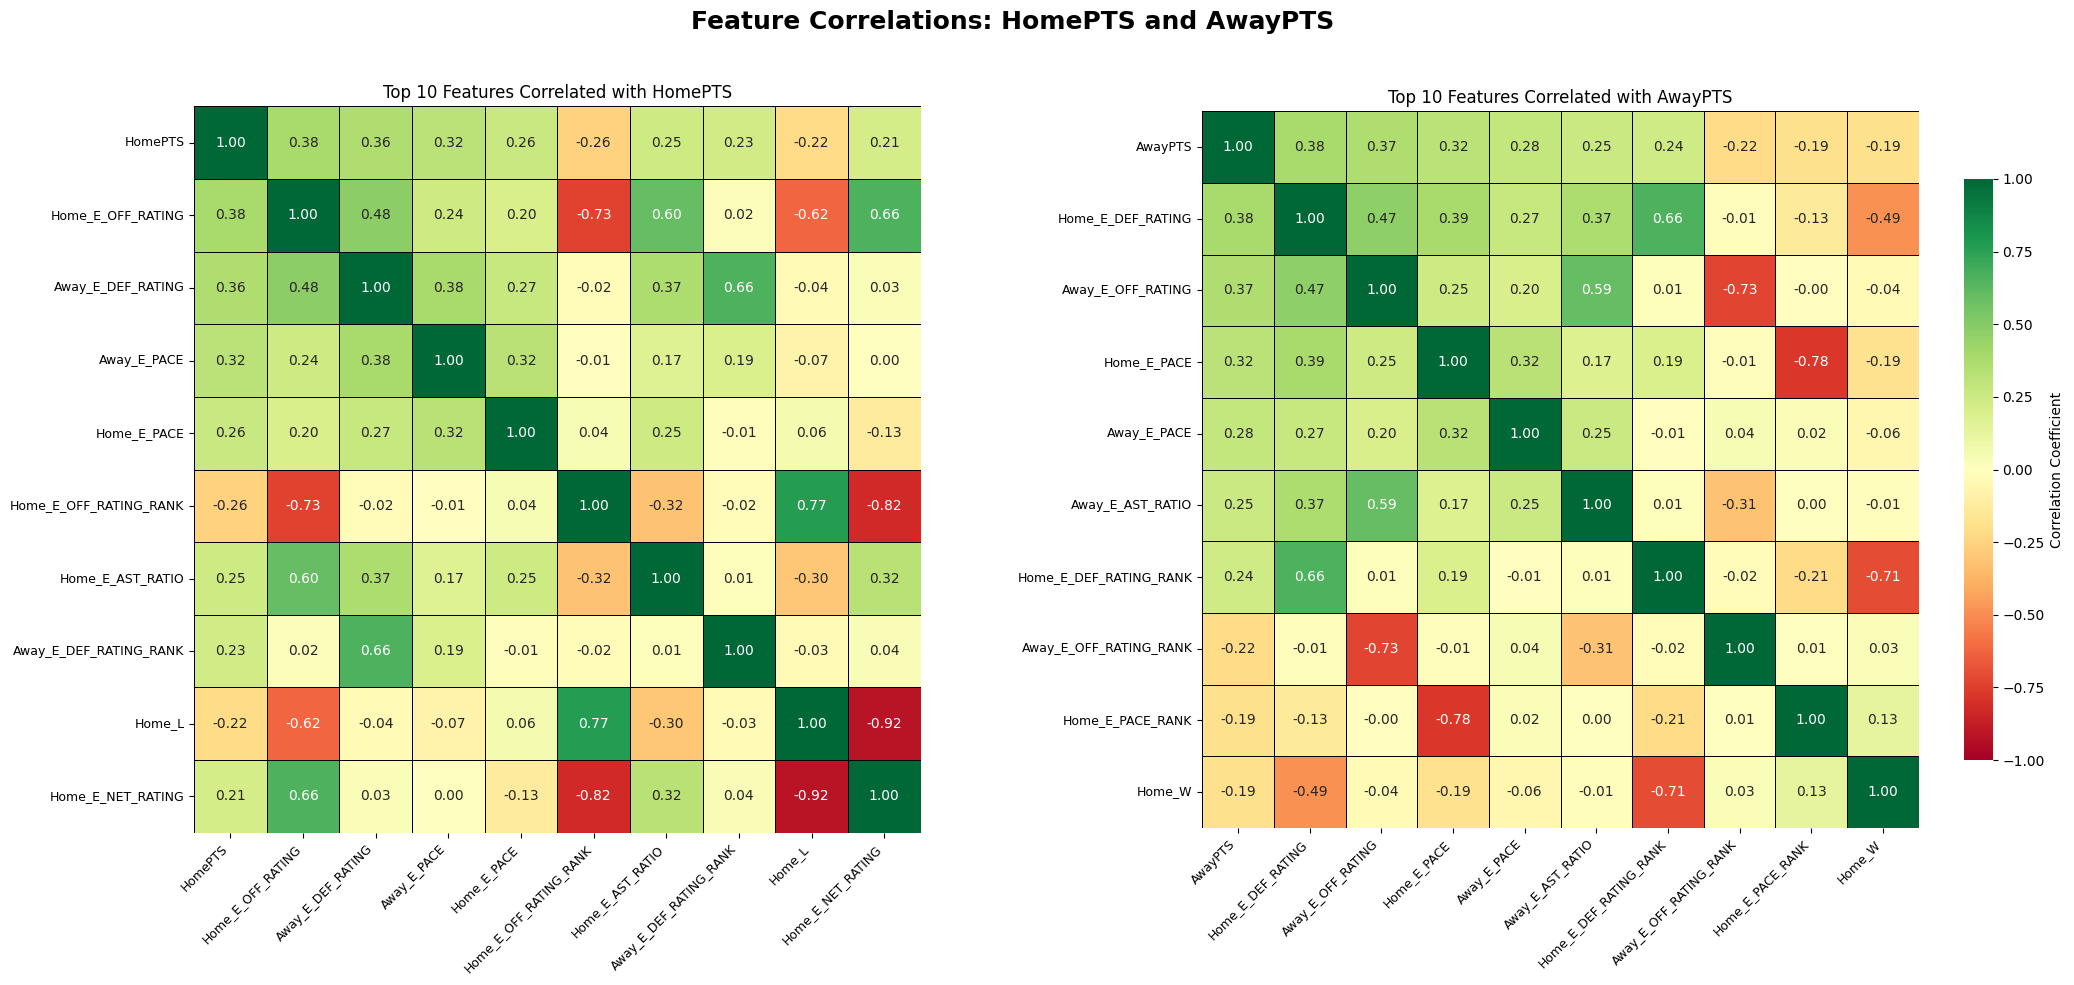

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

top10_home_feats = home_pts_corr.head(10).index.tolist()
top10_away_feats = away_pts_corr.head(10).index.tolist()

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# LEFT HEATMAP: HomePTS
home_matrix = df[top10_home_feats].corr()
sns.heatmap(home_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5,
            linecolor='black',
            cbar=False,
            ax=axes[0])

axes[0].set_title('Top 10 Features Correlated with HomePTS')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# RIGHT HEATMAP: AwayPTS
away_matrix = df[top10_away_feats].corr()
sns.heatmap(away_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5,
            linecolor='black',
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
            ax=axes[1])

axes[1].set_title('Top 10 Features Correlated with AwayPTS')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=9)

# Overall title
plt.suptitle('Feature Correlations: HomePTS and AwayPTS', 
             fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('correlation_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

Based on this heatmap, let's use the following for home points. Note that the assist ratios and rating ranks are pretty correlated features so we'll decline to use them. Statistics is an art so to speak.

1. Home offensive rating (`Home_E_OFF_RATING`)
2. Away defensive rating (`Away_E_DEF_RATING`)
3. Away pace (`Away_E_PACE`)
4. Home pace (`Home_E_PACE`)

We'll also include the home & away back to back indicator values. We'll not use the rest days due to the correlation being low.

6. Home back-to-back indicator (`Home_BackToBack`)
7. Away back-to-back indicator (`Away_BackToBack`)

Then we can literally just flip home and away above to obtain the set of features for away points, funnily enough!

Now let's add some rolling averages for features above.

In [58]:
df_selected = df[['GameID', 'GameDate', 'HomeTeam', 'AwayTeam', 'HomePTS', 'AwayPTS', 'Home_E_OFF_RATING', 'Away_E_OFF_RATING', 'Home_E_DEF_RATING', 'Away_E_DEF_RATING', 'Home_E_PACE', 'Away_E_PACE', 'Home_BackToBack', 'Away_BackToBack']]
display(df_selected.head())

,GameID,GameDate,HomeTeam,AwayTeam,HomePTS,AwayPTS,Home_E_OFF_RATING,Away_E_OFF_RATING,Home_E_DEF_RATING,Away_E_DEF_RATING,Home_E_PACE,Away_E_PACE,Home_BackToBack,Away_BackToBack
0,0021500001,2015-10-27,Atlanta Hawks,Detroit Pistons,94,106,103.0,103.3,99.3,102.6,99.1,97.8,0,0
1,0021500002,2015-10-27,Chicago Bulls,Cleveland Cavaliers,97,95,102.1,108.1,103.6,101.9,98.4,95.7,0,0
2,0021500003,2015-10-27,Golden State Warriors,New Orleans Pelicans,111,95,112.5,103.2,102.0,107.0,101.1,99.0,0,0
3,0021500004,2015-10-28,Orlando Magic,Washington Wizards,87,88,102.6,102.9,104.2,103.4,98.4,100.7,0,0
4,0021500005,2015-10-28,Boston Celtics,Philadelphia 76ers,112,95,103.9,96.6,100.7,106.8,101.2,100.2,0,0


In [81]:
def Add_Rolling_Averages(df, team_prefix, window):
    df[f'{team_prefix}_Rolling_PTS_Mean_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}PTS'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).mean()
    )
    df[f'{team_prefix}_Rolling_PTS_Std_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}PTS'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).std()
    )
    df[f'{team_prefix}_Rolling_OffRating_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}_E_OFF_RATING'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).mean()
    )
    df[f'{team_prefix}_Rolling_DefRating_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}_E_DEF_RATING'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).mean()
    )
    df[f'{team_prefix}_Rolling_Pace_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}_E_PACE'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).mean()
    )

    return df

df_rolling = df_selected.copy()
df_rolling = Add_Rolling_Averages(df_rolling, 'Home', 5)
df_rolling = Add_Rolling_Averages(df_rolling, 'Away', 5)
df_rolling = Add_Rolling_Averages(df_rolling, 'Home', 10)
df_rolling = Add_Rolling_Averages(df_rolling, 'Away', 10)

display(df_rolling.head())

,GameID,GameDate,HomeTeam,AwayTeam,HomePTS,AwayPTS,Home_E_OFF_RATING,Away_E_OFF_RATING,Home_E_DEF_RATING,Away_E_DEF_RATING,...,Home_Rolling_PTS_Mean_10,Home_Rolling_PTS_Std_10,Home_Rolling_OffRating_10,Home_Rolling_DefRating_10,Home_Rolling_Pace_10,Away_Rolling_PTS_Mean_10,Away_Rolling_PTS_Std_10,Away_Rolling_OffRating_10,Away_Rolling_DefRating_10,Away_Rolling_Pace_10
0,0021500001,2015-10-27,Atlanta Hawks,Detroit Pistons,94,106,103.0,103.3,99.3,102.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0021500002,2015-10-27,Chicago Bulls,Cleveland Cavaliers,97,95,102.1,108.1,103.6,101.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0021500003,2015-10-27,Golden State Warriors,New Orleans Pelicans,111,95,112.5,103.2,102.0,107.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0021500004,2015-10-28,Orlando Magic,Washington Wizards,87,88,102.6,102.9,104.2,103.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0021500005,2015-10-28,Boston Celtics,Philadelphia 76ers,112,95,103.9,96.6,100.7,106.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's wrap up and export now!

In [82]:
df_rolling.to_parquet("data/nba_rolling_features.parquet", index=False)

## First Pass Model Training

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.decomposition import PCA

# ----------------------------------------
# Load Engineered Dataset
# ----------------------------------------

df = pd.read_parquet("data/nba_features.parquet")

# Parse dates
df["GameDate"] = pd.to_datetime(df["GameDate"])

# ----------------------------------------
# Split Train (pre-2024) and Test (2024–2025 season)
# ----------------------------------------

cutoff_date = df["GameDate"].quantile(0.8)

train_df = df[df["GameDate"] < cutoff_date]
test_df = df[df["GameDate"] >= cutoff_date]

print(f"Train size: {len(train_df)} games")
print(f"Test size: {len(test_df)} games")

# ----------------------------------------
# Prepare Features and Target
# ----------------------------------------

y_train = train_df["HomePTS"]
X_train = train_df.drop(columns=["HomePTS", "TotalPoints", "AwayPTS", "GameDate"])

y_test = test_df["HomePTS"]
X_test = test_df.drop(columns=["HomePTS", "TotalPoints", "AwayPTS", "GameDate"])

# Handle missing values
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # fill test with training means!

# ----------------------------------------
# Scale Features
# ----------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA to scaled features
pca = PCA(n_components=0.95, svd_solver='full')  # retain 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# ----------------------------------------
# Define Models
# ----------------------------------------

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=8, random_state=42),
}

# ----------------------------------------
# Train and Evaluate Each Model
# ----------------------------------------

results = []
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")

    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

    predictions[name] = y_pred  # store predictions separately

# ----------------------------------------
# Display Results
# ----------------------------------------

results_df = pd.DataFrame(results)
print("\nFinal Model Evaluation on 2024–2025 Season:")
print(results_df)

# Save to CSV
results_df.to_csv("final_model_results_2024_2025.csv", index=False)

# ----------------------------------------
# Save Predictions for Each Model
# ----------------------------------------

for model_name, preds in predictions.items():
    test_results = test_df.copy()
    test_results[f"{model_name}_Predicted_TotalPoints"] = preds
    save_filename = model_name.replace(" ", "_").lower() + "_predictions_2024_2025.csv"
    test_results.to_csv(save_filename, index=False)
    print(f"Saved {model_name} predictions to {save_filename}")


Train size: 9573 games
Test size: 2401 games
Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training Random Forest...
Training Gradient Boosting...

Final Model Evaluation on 2024–2025 Season:
               Model   MAE   RMSE  R2 Score
0  Linear Regression  9.52  12.02    0.1094
1   Ridge Regression  9.52  12.02    0.1095
2   Lasso Regression  9.51  12.00    0.1114
3      Random Forest  9.67  12.14    0.0911
4  Gradient Boosting  9.76  12.29    0.0693
Saved Linear Regression predictions to linear_regression_predictions_2024_2025.csv
Saved Ridge Regression predictions to ridge_regression_predictions_2024_2025.csv
Saved Lasso Regression predictions to lasso_regression_predictions_2024_2025.csv
Saved Random Forest predictions to random_forest_predictions_2024_2025.csv
Saved Gradient Boosting predictions to gradient_boosting_predictions_2024_2025.csv


## New Rolling Features

In [83]:
df = pd.read_parquet("data/nba_rolling_features.parquet")
df = df.drop(['HomeTeam', 'AwayTeam', 'GameID'], axis=1)

# Parse dates
df["GameDate"] = pd.to_datetime(df["GameDate"])

First let's set the columns per model.

In [85]:
home_model_features = ["Home_E_OFF_RATING", "Away_E_DEF_RATING", "Away_E_PACE", "Home_E_PACE", "Home_BackToBack", "Away_BackToBack"]
home_model_features += [col for col in df.columns if 
    col.startswith('Home_Rolling_OffRating_')
    or col.startswith('Away_Rolling_DefRating_')
    or col.startswith('Home_Rolling_Pace_') 
    or col.startswith('Away_Rolling_Pace_')
    or col.startswith('Home_Rolling_PTS_')
]

home_model_features

['Home_E_OFF_RATING',
 'Away_E_DEF_RATING',
 'Away_E_PACE',
 'Home_E_PACE',
 'Home_BackToBack',
 'Away_BackToBack',
 'Home_Rolling_PTS_Mean_5',
 'Home_Rolling_PTS_Std_5',
 'Home_Rolling_OffRating_5',
 'Home_Rolling_Pace_5',
 'Away_Rolling_DefRating_5',
 'Away_Rolling_Pace_5',
 'Home_Rolling_PTS_Mean_10',
 'Home_Rolling_PTS_Std_10',
 'Home_Rolling_OffRating_10',
 'Home_Rolling_Pace_10',
 'Away_Rolling_DefRating_10',
 'Away_Rolling_Pace_10']

In [86]:
away_model_features = ["Away_E_OFF_RATING", "Home_E_DEF_RATING", "Away_E_PACE", "Home_E_PACE", "Home_BackToBack", "Away_BackToBack"]
away_model_features += [col for col in df.columns if 
    col.startswith('Away_Rolling_OffRating_')
    or col.startswith('Home_Rolling_DefRating_')
    or col.startswith('Home_Rolling_Pace_') 
    or col.startswith('Away_Rolling_Pace_')
    or col.startswith('Away_Rolling_PTS_')
]

away_model_features

['Away_E_OFF_RATING',
 'Home_E_DEF_RATING',
 'Away_E_PACE',
 'Home_E_PACE',
 'Home_BackToBack',
 'Away_BackToBack',
 'Home_Rolling_DefRating_5',
 'Home_Rolling_Pace_5',
 'Away_Rolling_PTS_Mean_5',
 'Away_Rolling_PTS_Std_5',
 'Away_Rolling_OffRating_5',
 'Away_Rolling_Pace_5',
 'Home_Rolling_DefRating_10',
 'Home_Rolling_Pace_10',
 'Away_Rolling_PTS_Mean_10',
 'Away_Rolling_PTS_Std_10',
 'Away_Rolling_OffRating_10',
 'Away_Rolling_Pace_10']

In [95]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ----------------------------------------
# Split Train (pre-2024) and Test (2024–2025 season)
# ----------------------------------------

cutoff_date = df["GameDate"].quantile(0.8)

train_df = df[df["GameDate"] < cutoff_date]
test_df = df[df["GameDate"] >= cutoff_date]

print(f"Train size: {len(train_df)} games")
print(f"Test size: {len(test_df)} games")

# ----------------------------------------
# Prepare Features and Target
# ----------------------------------------

# Drop NA values; inputting mean causes data leakage in rolling averages
train_df = train_df.dropna()
test_df = test_df.dropna()


# Split HomePTS and AwayPTS
y_train = train_df[["HomePTS", "AwayPTS"]]
X_train = train_df.drop(columns=["HomePTS", "AwayPTS", "GameDate"])

y_test = test_df[["HomePTS", "AwayPTS"]]
X_test = test_df.drop(columns=["HomePTS", "AwayPTS", "GameDate"])

# ----------------------------------------
# Scale Features
# ----------------------------------------

scaled_data = {
    'HomePTS': {},
    'AwayPTS': {}
}
home_scaler = StandardScaler()
scaled_data['HomePTS']['X_train'] = home_scaler.fit_transform(X_train[home_model_features])
scaled_data['HomePTS']['X_test'] = home_scaler.transform(X_test[home_model_features])

away_scaler = StandardScaler()
scaled_data['AwayPTS']['X_train'] = away_scaler.fit_transform(X_train[away_model_features])
scaled_data['AwayPTS']['X_test'] = away_scaler.transform(X_test[away_model_features])

# Apply PCA to scaled features
# pca = PCA(n_components=0.95, svd_solver='full')  # retain 95% variance
# X_train_pca = pca.fit_transform(X_train_scaled)
# X_test_pca = pca.transform(X_test_scaled)

# ----------------------------------------
# Define Models
# ----------------------------------------

models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.01),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.025, random_state=5105),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.025, random_state=5105),
}

# ----------------------------------------
# Train and Evaluate Each Model
# ----------------------------------------

results = []
predictions = {model: {} for model in models.keys()}

for point in ["HomePTS", "AwayPTS"]:
    if point == "HomePTS":
        model_features = home_model_features
    else:
        model_features = away_model_features
    
    for name, model in models.items():
        print(f"Training {name} for {point}...")

        X_train_scaled = scaled_data[point]['X_train']
        X_test_scaled = scaled_data[point]['X_test']
        model.fit(X_train_scaled, y_train[point])
        y_pred = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test[point], y_pred)
        rmse = root_mean_squared_error(y_test[point], y_pred)
        r2 = r2_score(y_test[point], y_pred)

        results.append({
            "Model": name,
            "Predicting": point,
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "R2 Score": round(r2, 4)
        })

        predictions[name][point] = y_pred  # store predictions separately

# ----------------------------------------
# Display Results
# ----------------------------------------

results_df = pd.DataFrame(results)
print("\nFinal Model Evaluation on 2024–2025 Season:")
print(results_df)

# Save to CSV
results_df.to_csv("predictions/final_model_results_2024_2025.csv", index=False)

# ----------------------------------------
# Save Predictions for Each Model
# ----------------------------------------

for model_name, preds in predictions.items():
    test_results = test_df.copy()
    test_results[model_name.replace(" ", "_") + "_HomePTS"] = preds['HomePTS']
    test_results[model_name.replace(" ", "_") + "_AwayPTS"] = preds['AwayPTS']
    save_filename = "".join(["predictions/", model_name.replace(" ", "_").lower(), "_predictions_v3.csv"])
    test_results.to_csv(save_filename, index=False)
    print(f"Saved {model_name} predictions to {save_filename}")


Train size: 9622 games
Test size: 2410 games
Training Linear Regression for HomePTS...
Training Lasso Regression for HomePTS...
Training XGBoost for HomePTS...
Training LightGBM for HomePTS...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3347
[LightGBM] [Info] Number of data points in the train set: 9550, number of used features: 18
[LightGBM] [Info] Start training from score 110.548377


d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training Linear Regression for AwayPTS...
Training Lasso Regression for AwayPTS...
Training XGBoost for AwayPTS...
Training LightGBM for AwayPTS...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3356
[LightGBM] [Info] Number of data points in the train set: 9550, number of used features: 18
[LightGBM] [Info] Start training from score 108.247539

Final Model Evaluation on 2024–2025 Season:
               Model Predicting   MAE   RMSE  R2 Score
0  Linear Regression    HomePTS  9.19  11.43    0.1954
1   Lasso Regression    HomePTS  9.19  11.42    0.1963
2            XGBoost    HomePTS  9.28  11.55    0.1775
3           LightGBM    HomePTS  9.22  11.47    0.1889
4  Linear Regression    AwayPTS  9.23  11.57    0.1831
5   Lasso Regression    AwayPTS  9.23  11.57    0.1832
6            XGBoost    AwayPTS  9.31  11.71    0.1631
7           LightGBM    

Let's sample 100 games from the test data and show the predictions across the three models.

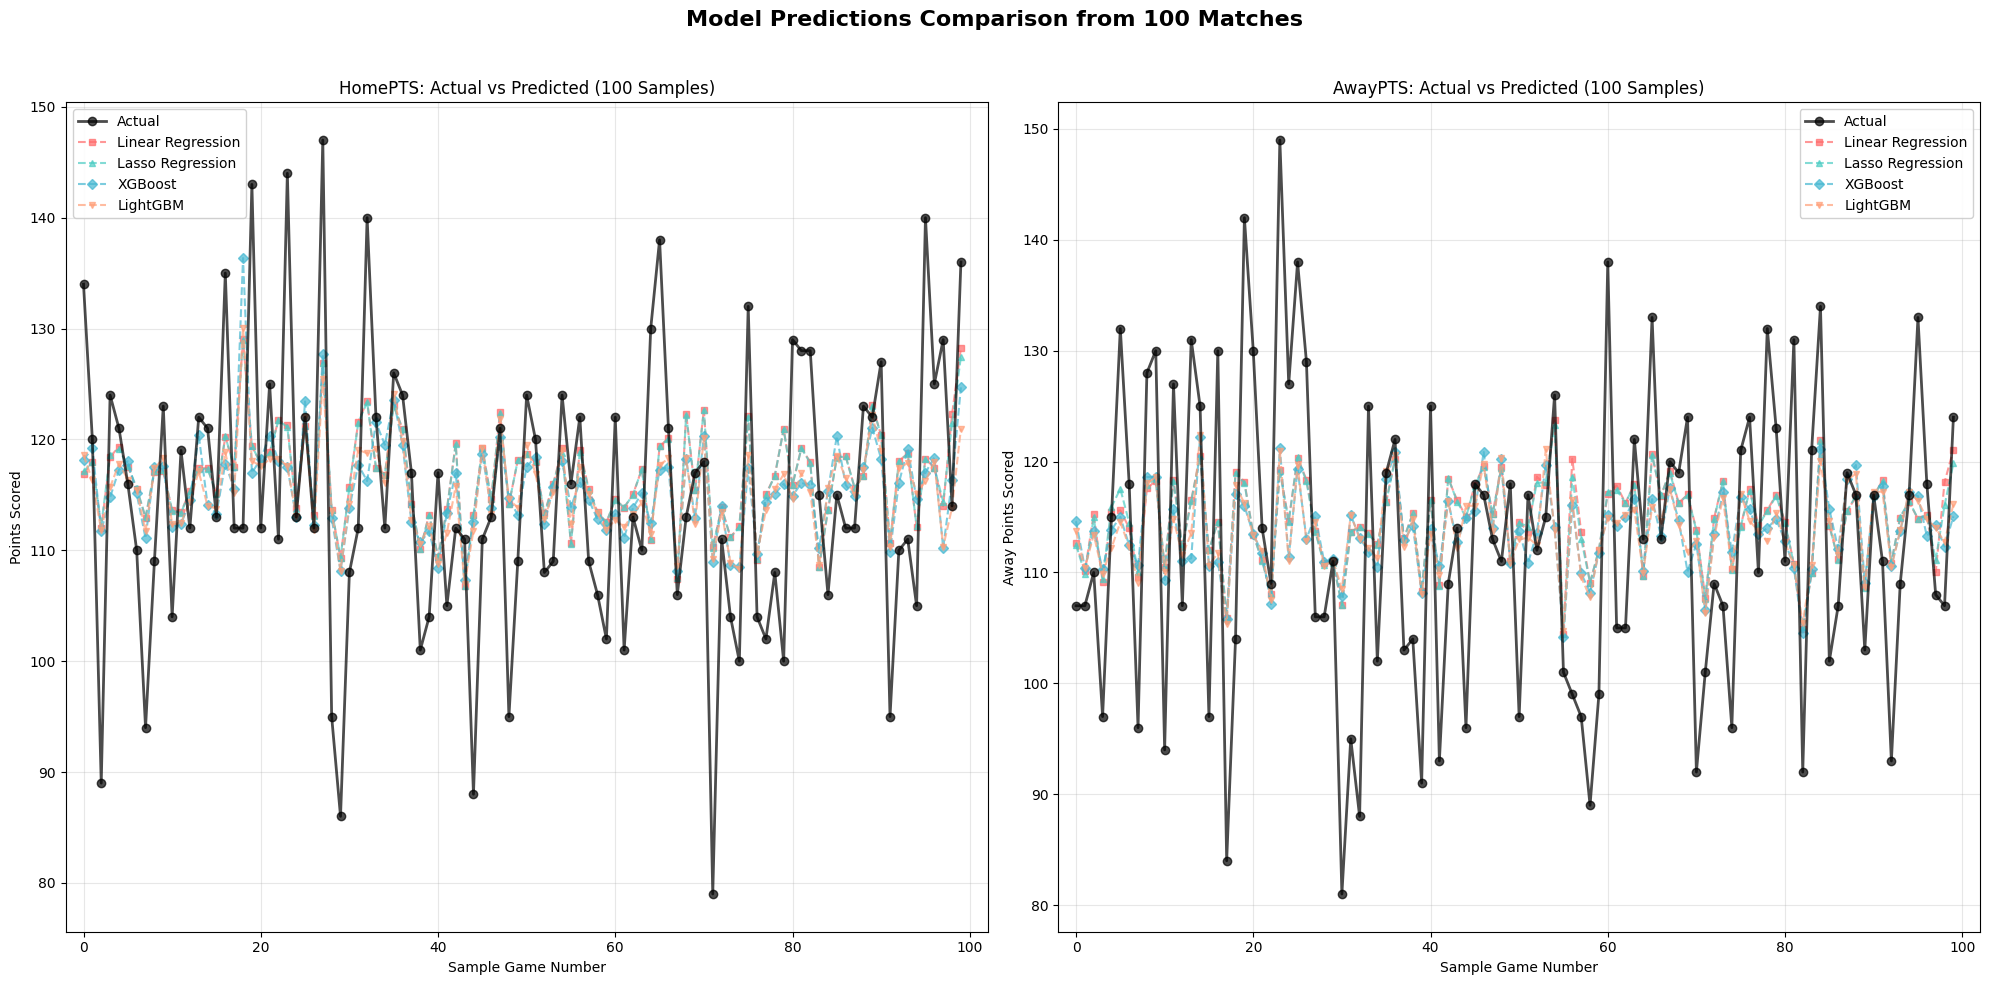

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_indices = np.random.choice(len(test_df), size=100, replace=False)
sample_indices = np.sort(sample_indices)  # Sort for better visualization

actual_home = test_df['HomePTS'].iloc[sample_indices].values
actual_away = test_df['AwayPTS'].iloc[sample_indices].values

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
x = np.arange(100)

### HomePTS
ax1 = axes[0]

# Plot actual values as baseline
ax1.plot(x, actual_home, 'o-', color='black', linewidth=2, markersize=6, 
            label='Actual', alpha=0.7, zorder=10)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
markers = ['s', '^', 'D', 'v', 'p']

for idx, (model_name, preds) in enumerate(predictions.items()):
    home_pred = preds['HomePTS'][sample_indices]
    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]
    
    ax1.plot(x, home_pred, marker=marker, linestyle='--', 
            color=color, linewidth=1.5, markersize=5,
            label=model_name, alpha=0.7)

ax1.set_xlabel('Sample Game Number')
ax1.set_ylabel('Points Scored')
ax1.set_title('HomePTS: Actual vs Predicted (100 Samples)')
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2, n_samples + 2)

### AwayPTS
ax2 = axes[1]

# Plot actual values as baseline
ax2.plot(x, actual_away, 'o-', color='black', linewidth=2, markersize=6,
            label='Actual', alpha=0.7, zorder=10)

# Plot predictions for each model
for idx, (model_name, preds) in enumerate(predictions.items()):
    away_pred = preds['AwayPTS'][sample_indices]
    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]
    
    ax2.plot(x, away_pred, marker=marker, linestyle='--',
            color=color, linewidth=1.5, markersize=5,
            label=model_name, alpha=0.7)

ax2.set_xlabel('Sample Game Number')
ax2.set_ylabel('Away Points Scored')
ax2.set_title('AwayPTS: Actual vs Predicted (100 Samples)')
ax2.legend(loc='best', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 100 + 2)

# Overall title
plt.suptitle('Model Predictions Comparison from 100 Matches', 
                fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()